# 问题四 求解讲解：技术演进分析与前沿预测

**任务拆解**：

1. 建立动力学或因果推断模型，**分离并量化规模扩张与非规模技术进步各自的贡献占比**；
2. 在算力增长放缓情景下，预测未来 12 / 24 个月开源大语言模型能力的**前沿边界**，并给出不确定性分析；
3. 须说明四件口径：综合能力度量方式、开源筛选规则、pretrained 与 chat/finetuned 的区分、时间轴口径；
4. 须用 C6（或 C5）建立 Loss→Benchmark 映射并讨论映射误差，桥接数据**按可比性等级区分使用**；须使用 C4 的算力/数据量/开源权重字段；须对 C8 做至少一项**逐任务聚合**分析。

**四问的桥接**：前三问以交叉熵损失为目标，本问以多维 Benchmark 得分为度量，因此 Loss→Benchmark 映射是把前面结论"翻译"成能力收益的关键环节。

> **运行说明**
> - 本 notebook 放在 `求解/问题X/` 目录下，请在该目录下打开；`_common.py` 会自动定位附件目录、输出目录与字体。
> - 依赖：`numpy`、`pandas`、`scipy`、`matplotlib`（无需 GPU）。
> - 单元已带上次真实运行的输出，直接看即可；想复现就从上到下 Run All。
> - 结果 CSV 写入 `结果/`，图片写入 `图片/`。

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
# 让本 notebook 能 import 到 求解/_common.py（notebook 位于 求解/问题X/ 下）
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from _common import *   # noqa: F401,F403

# 在 Jupyter 中运行时，让 save_fig 除保存文件外也把图片内联显示出来。
# 注意必须改 _common 模块的属性：脚本头部还会再执行一次 `from _common import *`，
# 只改本地名字会被覆盖。
try:
    from IPython.display import display as _ipy_display, Image as _ipy_Image
    import _common as _cm
    _orig_save_fig = _cm.save_fig
    def save_fig(fig, name_cn, dpi=300):
        _orig_save_fig(fig, name_cn, dpi)
        try:
            _ipy_display(_ipy_Image(filename=os.path.join(_cm.FIG_DIR, name_cn + '.png')))
        except Exception:
            pass
    _cm.save_fig = save_fig
except Exception:
    pass   # 非 Jupyter 环境（直接跑脚本）不需要内联显示

print('附件目录:', DATA_DIR)
print('结果目录:', OUT_DIR)
print('图片目录:', FIG_DIR)


附件目录: C:\Users\qq190\Desktop\第二十三届中国研究生数学建模竞赛 - 中文题目\中文题目\F题\real_attachments
结果目录: C:\Users\qq190\Desktop\研赛（华为杯）f题\研赛（华为杯）_2026-09-23_08-27-48\求解\问题四\结果
图片目录: C:\Users\qq190\Desktop\研赛（华为杯）f题\研赛（华为杯）_2026-09-23_08-27-48\求解\问题四\图片


### 准备：模块头与公共工具函数

这一段是脚本自己的模块头（导入 + `save_csv_safe` 等公共小工具）。notebook 环境下 `__file__` 不存在，
因此原来那行 `sys.path.insert(... __file__ ...)` 已在上面的第 1 个单元用等价方式取代。

> 小技巧：`save_csv_safe` 会在目标 CSV 被 Excel 等程序占用时自动改存为 `*_new.csv`，保证整条流水线不中断。

In [2]:
# -*- coding: utf-8 -*-
"""
问题四：技术演进分析与前沿预测
数据：C1/C2 排行榜、C3 时序、C4 Epoch 宏观元数据、C5/C6 Loss-Benchmark 桥接、C7 架构、C8 逐任务 JSON
流程：1) 明确口径：时间轴(提交日期)、开源口径(开源权重+许可允许研究复现)、模型类型(pretrained/chat)
      2) C8 逐任务聚合（必做），并与 C1 六维交叉校验
      3) C6 桥接（按可比性分层）+ C5 对照，建立 Loss -> Benchmark 映射
      4) 面板回归（含年份固定效应）分离规模扩张与非规模技术进步贡献
      5) 情景设定下 logistic 饱和外推 12/24 个月能力前沿 + 残差 bootstrap 不确定性
      6) C4 宏观算力/数据量/开源权重证据，支撑"算力增长放缓"情景
输出：图片到 图片/，结果 CSV 到 结果/
"""
import sys, os, json, glob, re, collections
# （sys.path 已在第 1 个代码单元中设置，notebook 里不需要 __file__）
from _common import *   # noqa: F401,F403
from scipy.optimize import curve_fit

DATA = data_path
C_DIR = os.path.join(DATA_DIR, 'C_efficiency_evolution')

def save_csv_safe(df, name_cn):
    p = os.path.join(OUT_DIR, name_cn)
    try:
        df.to_csv(p, index=False, encoding='utf-8-sig')
    except PermissionError:
        alt = p.replace('.csv', '_new.csv')
        df.to_csv(alt, index=False, encoding='utf-8-sig')
        print('  ! %s 被占用，已改存为 %s' % (name_cn, os.path.basename(alt)))

TASKS = ['IFEval', 'BBH', 'MATH Lvl 5', 'GPQA', 'MUSR', 'MMLU-PRO']


## 第 1 步：三套口径界定与筛选漏斗

本问最容易失分的地方不是模型，而是**口径没说清**。本文显式定义三件事：

1. **时间轴**：统一以 C1 的 `Submission Date`（提交日期）为基准，折算为连续时间 $t=\text{年份}-2019+(\text{月}-0.5)/12$。不采用发布日期或版本日期，因为 Leaderboard 的评测结果在提交时冻结、且该字段完整无缺失。
2. **开源口径**：要求 (a) 权重可获取（pretrained/持续预训练/chat/域内微调）且 (b) Hub License 允许研究与复现——采用 apache-2.0、mit、gpl-3.0、cc-by-4.0、mpl-2.0、bsd-3-clause、llama2/3.x、gemma 等白名单，**排除 cc-by-nc 系列（非商用）、creativeml-openrail、bigscience-bloom-rail 及未知许可**。
3. **模型类型**：区分 pretrained（基础模型）与 chat/finetuned（对齐后模型）；base 合并模型与多模态模型不并入主分析，因为前者不是独立训练过程、后者任务构成不同。

下面逐层打印筛选漏斗，让"2,346 条样本是怎么来的"完全可追溯。

In [3]:
# ============ 1. C1 排行榜：口径定义与筛选 ============
lb = pd.read_csv(os.path.join(C_DIR, 'leaderboard_cleaned.csv'))
lb['P'] = pd.to_numeric(lb['#Params (B)'], errors='coerce')
lb['date'] = pd.to_datetime(lb['Submission Date'], errors='coerce')
lb['Year'] = lb['date'].dt.year
lb['avg'] = pd.to_numeric(lb['Average ⬆️'], errors='coerce')
for t in TASKS:
    lb[t] = pd.to_numeric(lb[t], errors='coerce')

TYPE_PRE = ['🟢 pretrained', '🟩 continuously pretrained']
TYPE_CHAT = ['💬 chat models (RLHF, DPO, IFT, ...)',
             '🔶 fine-tuned on domain-specific datasets']
TYPE_EXCL = ['🤝 base merges and moerges', '🌸 multimodal', '❓ other']

PERMISSIVE = {'apache-2.0', 'mit', 'gpl-3.0', 'cc-by-4.0', 'mpl-2.0', 'bsd-3-clause',
              'llama2', 'llama3', 'llama3.1', 'llama3.2', 'llama3.3', 'gemma',
              'cc-by-sa-4.0', 'openrail'}

def license_ok(x):
    """许可是否允许研究与复现（非商用/受限/未知一律排除）。"""
    return str(x).strip().lower() in PERMISSIVE

lb['license_ok'] = lb['Hub License'].map(license_ok)
lb['type_group'] = np.where(lb['Type'].isin(TYPE_PRE), 'pretrained',
                            np.where(lb['Type'].isin(TYPE_CHAT), 'chat/finetuned', '其他'))
lb['six_complete'] = lb[TASKS].notna().all(axis=1)

funnel = [{'层级': 'C1 全量记录', 'n': len(lb)},
          {'层级': '六维得分完整', 'n': int(lb.six_complete.sum())}]
core = lb[lb.six_complete & lb.date.notna() & lb.P.notna()]
funnel.append({'层级': '时间/参数/六维齐备', 'n': len(core)})
core_o = core[core.license_ok]
funnel.append({'层级': '许可允许研究复现（开源口径）', 'n': len(core_o)})
core_pt = core_o[core_o.type_group.eq('pretrained')]
core_ch = core_o[core_o.type_group.eq('chat/finetuned')]
funnel.append({'层级': '  其中 pretrained', 'n': len(core_pt)})
funnel.append({'层级': '  其中 chat/finetuned', 'n': len(core_ch)})
save_csv_safe(pd.DataFrame(funnel), '筛选漏斗.csv')
print('=== 1. 数据口径与筛选漏斗 ===')
print(pd.DataFrame(funnel).to_string(index=False))
print('  时间轴口径：以 C1 的 Submission Date（提交日期）为基准。')
print('  开源口径：权重可获取（pretrained/持续预训练/chat/微调）且 Hub License 允许研究复现。')
print('  模型类型口径：pretrained 与 chat/finetuned 分组统计；base 合并模型（%d 条）、'
      '多模态（%d 条）不并入主分析。'
      % (int(lb['Type'].eq(TYPE_EXCL[0]).sum()), int(lb['Type'].eq(TYPE_EXCL[1]).sum())))
print('  提交日期范围：%s ~ %s' % (str(lb.date.min())[:10], str(lb.date.max())[:10]))


=== 1. 数据口径与筛选漏斗 ===
                 层级    n
            C1 全量记录 4576
             六维得分完整 4576
         时间/参数/六维齐备 4561
     许可允许研究复现（开源口径） 2346
      其中 pretrained  231
  其中 chat/finetuned 1497
  时间轴口径：以 C1 的 Submission Date（提交日期）为基准。
  开源口径：权重可获取（pretrained/持续预训练/chat/微调）且 Hub License 允许研究复现。
  模型类型口径：pretrained 与 chat/finetuned 分组统计；base 合并模型（1724 条）、多模态（9 条）不并入主分析。
  提交日期范围：2024-06-08 ~ 2025-03-13


## 第 2 步：附件 C8 的逐任务聚合（本题必做项）

数据说明明确要求"须对 C8 做至少一项逐任务聚合分析，不得仅使用汇总表"。C8 是 1,863 个模型子目录、1,958 个评测 JSON，本文按目录取**最新可解析记录**，提取每个模型在各任务上的原始指标（按 `acc_norm`、`acc`、`prompt_level_loose_acc`、`inst_level_loose_acc`、`exact_match` 的优先级选取），解析出 BBH 24 项、MATH-Hard 7 项、GPQA 3 项、MUSR 3 项共 **37 个子任务维度**。

**一个关键口径差异**：C8 存的是原始指标，而 C1 存的是官方按随机基线归一化后的六维得分，例如

$$\text{GPQA}=\frac{\text{raw}-0.25}{0.75},\qquad \text{MMLU-PRO}=\frac{\text{raw}-0.10}{0.90},\qquad \text{IFEval}=\frac{\text{prompt\_strict}+\text{inst\_strict}}{2}$$

所以两者存在系统性水平差。本文的处理是：**跨模型得分分析用 C1，逐任务结构分析在 C8 的原始指标空间内做**，并用秩相关（Spearman）作为两者的衔接验证。

In [4]:
# ============ 2. C8 逐任务聚合（必用） ============
def norm_name(s):
    return re.sub(r'[^a-z0-9]', '', str(s).lower())

C8_DIR = os.path.join(C_DIR, 'detailed_results')
dirs = sorted(d for d in os.listdir(C8_DIR) if os.path.isdir(os.path.join(C8_DIR, d)))
METRIC_PREF = ['acc_norm,none', 'acc,none', 'prompt_level_loose_acc,none',
               'inst_level_loose_acc,none', 'exact_match,none']
recs, broken = [], 0
for d in dirs:
    fl = sorted(glob.glob(os.path.join(C8_DIR, d, '*.json')))
    if not fl:
        continue
    ok = False
    for f in reversed(fl):
        try:
            o = json.load(open(f, encoding='utf-8'))
            res = o.get('results')
            if not isinstance(res, dict) or not res:
                continue
        except Exception:
            broken += 1
            continue
        rec = {'dir': d, 'json_model_name': o.get('model_name', ''),
               'file': os.path.basename(f)}
        for k, v in res.items():
            if not isinstance(v, dict):
                continue
            for mk in METRIC_PREF:
                if isinstance(v.get(mk), (int, float)):
                    rec[k] = float(v[mk]) * 100.0
                    break
        recs.append(rec)
        ok = True
        break
    if not ok:
        broken += 1

c8 = pd.DataFrame(recs)
print('\n=== 2. C8 逐任务聚合（必做）===')
print('  模型目录 %d 个；成功解析 %d 个；跳过损坏/无有效记录 %d 个' % (len(dirs), len(c8), broken))
save_csv_safe(c8.fillna(''), 'C8逐任务解析结果.csv')

C8_MAP = {'IFEval': 'leaderboard_ifeval', 'BBH': 'leaderboard_bbh',
          'MATH Lvl 5': 'leaderboard_math_hard', 'GPQA': 'leaderboard_gpqa',
          'MUSR': 'leaderboard_musr', 'MMLU-PRO': 'leaderboard_mmlu_pro'}
for t, k in C8_MAP.items():
    c8[t] = c8[k] if k in c8.columns else np.nan
c8['key'] = c8['dir'].map(norm_name)

lb['key'] = lb['Model'].map(norm_name)
core_o = core_o.assign(key=core_o['Model'].map(norm_name))
mrg = lb[['key'] + TASKS].merge(c8[['key'] + TASKS], on='key', suffixes=('_C1', '_C8'))
chk_rows = []
for t in TASKS:
    a = pd.to_numeric(mrg[t + '_C1'], errors='coerce')
    bq = pd.to_numeric(mrg[t + '_C8'], errors='coerce')
    okm = a.notna() & bq.notna()
    chk_rows.append({'任务': t, '匹配模型数': int(okm.sum()),
                     'Pearson_r': float(np.corrcoef(a[okm], bq[okm])[0, 1]) if okm.sum() > 2 else np.nan,
                     'Spearman_rho': float(stats.spearmanr(a[okm], bq[okm]).statistic)
                     if okm.sum() > 2 else np.nan,
                     '平均绝对偏差': float(np.mean(np.abs(a[okm] - bq[okm]))) if okm.sum() else np.nan})
chk = pd.DataFrame(chk_rows)
save_csv_safe(chk, 'C8与C1一致性校验.csv')
print('  C8 与 C1 逐维一致性（规范化模型名匹配，命中 %d 个模型）：' % len(mrg))
print(chk.to_string(index=False))
print('  口径说明：C8 存的是各任务的原始指标（acc/acc_norm/exact_match），'
      'C1 存的是官方按随机基线归一化后的六维得分（例如 GPQA=(raw-0.25)/0.75、'
      'MMLU-PRO=(raw-0.10)/0.90、IFEval=(prompt_strict+inst_strict)/2），'
      '故两者存在系统性水平差但秩一致性很高。因此：跨模型得分分析用 C1，'
      '逐任务结构分析在 C8 的原始指标空间内进行。')

# 逐任务（子任务）聚合：BBH 24 项、MATH 7 项、GPQA 3 项、MUSR 3 项
SUB_PREFIX = {'BBH子任务': 'leaderboard_bbh_', 'MATH子任务': 'leaderboard_math_',
              'GPQA子集': 'leaderboard_gpqa_', 'MUSR子任务': 'leaderboard_musr_'}
sub_cols = {}
for grp, pre in SUB_PREFIX.items():
    cols = [c for c in c8.columns if c.startswith(pre) and c.count('_') >= 2]
    cols = [c for c in cols if c not in ('leaderboard_bbh', 'leaderboard_musr',
                                         'leaderboard_gpqa', 'leaderboard_math_hard')]
    sub_cols[grp] = cols
print('  C8 子任务维度数：' + '，'.join('%s %d 项' % (k, len(v)) for k, v in sub_cols.items()))

# 子任务前沿与剩余空间（限定在开源筛选后的模型集合上）
screened_keys = set(core_o['key'])
c8s = c8[c8.key.isin(screened_keys)]
sub_rows = []
for grp, cols in sub_cols.items():
    for c in cols:
        s = pd.to_numeric(c8s[c], errors='coerce').dropna()
        if len(s) < 10:
            continue
        sub_rows.append({'类别': grp, '子任务': c.replace('leaderboard_', ''), '样本数': len(s),
                         '最优得分': float(s.max()),
                         '前5%均值': float(s.nlargest(max(1, int(len(s) * 0.05))).mean()),
                         '中位数': float(s.median()),
                         '剩余空间_%': float((100 - s.max()) / 100 * 100)})
sub_df = pd.DataFrame(sub_rows)
save_csv_safe(sub_df, 'C8逐任务聚合.csv')
print('\n  子任务层面最弱 6 项（剩余空间最大）：')
print(sub_df.nlargest(6, '剩余空间_%')[['类别', '子任务', '样本数', '最优得分', '前5%均值',
                                        '剩余空间_%']].to_string(index=False))

CAT_ROWS = []
for grp, cols in sub_cols.items():
    s = pd.to_numeric(c8s[cols].stack(), errors='coerce').dropna()
    CAT_ROWS.append({'类别': grp, '维度数': len(cols), '平均最优得分': float(
        np.mean([pd.to_numeric(c8s[c], errors='coerce').max() for c in cols])),
        '整体前5%均值': float(s.quantile(0.95)), '整体中位数': float(s.median())})
save_csv_safe(pd.DataFrame(CAT_ROWS), 'C8子任务类别汇总.csv')
print('\n  子任务类别汇总：')
print(pd.DataFrame(CAT_ROWS).to_string(index=False))



=== 2. C8 逐任务聚合（必做）===
  模型目录 1863 个；成功解析 1860 个；跳过损坏/无有效记录 7 个
  C8 与 C1 逐维一致性（规范化模型名匹配，命中 1900 个模型）：
        任务  匹配模型数  Pearson_r  Spearman_rho    平均绝对偏差
    IFEval   1896   0.986654      0.986957  2.884010
       BBH   1898   0.997773      0.997029 21.060392
MATH Lvl 5   1897   0.803002      0.811650  3.474679
      GPQA   1894   0.987140      0.991930 23.379296
      MUSR   1894   0.973466      0.977356 30.730238
  MMLU-PRO   1896   0.998190      0.998358  7.560751
  口径说明：C8 存的是各任务的原始指标（acc/acc_norm/exact_match），C1 存的是官方按随机基线归一化后的六维得分（例如 GPQA=(raw-0.25)/0.75、MMLU-PRO=(raw-0.10)/0.90、IFEval=(prompt_strict+inst_strict)/2），故两者存在系统性水平差但秩一致性很高。因此：跨模型得分分析用 C1，逐任务结构分析在 C8 的原始指标空间内进行。
  C8 子任务维度数：BBH子任务 24 项，MATH子任务 7 项，GPQA子集 3 项，MUSR子任务 3 项

  子任务层面最弱 6 项（剩余空间最大）：
     类别                                         子任务  样本数      最优得分     前5%均值    剩余空间_%
MATH子任务              math_intermediate_algebra_hard  962 31.785714 20.111607 68.214286
MATH子任务                       math_precalculus_hard 

## 第 3 步：Loss—Benchmark 桥接（按可比性分层）

$$\bar B=a+b\,L$$

C6 的 `Loss_Comparability` 字段区分"高可比（同模型同验证集）"与"中可比（Loss 来自不同论文）"，**必须分层使用**，否则会把不同验证集的损失混在一起回归。本文同时报告分层结果与全样本结果，并用 C5（原始桥接表）做对照。

映射误差对结论的影响必须显式讨论：如果 $R^2$ 很低，那么"损失改善换算成多少能力分"只能做方向性判断。

In [5]:
# ============ 3. Loss - Benchmark 桥接（C6 主用，按可比性分层；C5 对照） ============
br = pd.read_csv(os.path.join(C_DIR, 'loss_benchmark_bridge_expanded.csv'))
br['cmp'] = np.where(br['Loss_Comparability'].str.startswith('High'), '高可比',
                     '中可比')
print('\n=== 3. Loss-Benchmark 桥接（C6 扩展桥接）===')
bridge_rows, fits = [], {}
for lvl in ['高可比', '中可比', '全样本']:
    d = br if lvl == '全样本' else br[br.cmp.eq(lvl)]
    sl, ic = np.polyfit(d.Val_Loss, d.LB_Average, 1)
    pred = ic + sl * d.Val_Loss
    fits[lvl] = (sl, ic)
    bridge_rows.append({'可比性': lvl, 'n': len(d),
                        'Pearson_r': float(np.corrcoef(d.Val_Loss, d.LB_Average)[0, 1]),
                        'Spearman_rho': float(stats.spearmanr(d.Val_Loss, d.LB_Average).statistic),
                        '斜率': float(sl), '截距': float(ic),
                        'MAPE_%': float(np.mean(np.abs(pred - d.LB_Average) / d.LB_Average) * 100),
                        'R2': float(1 - np.sum((d.LB_Average - pred) ** 2)
                                    / np.sum((d.LB_Average - d.LB_Average.mean()) ** 2))})
bridge_df = pd.DataFrame(bridge_rows)
save_csv_safe(bridge_df, 'Loss_Benchmark映射.csv')
print(bridge_df.to_string(index=False))
br['pred'] = fits['全样本'][1] + fits['全样本'][0] * br.Val_Loss
save_csv_safe(br[['Model', 'N_params_B', 'D_tokens_B', 'Val_Loss', 'LB_Average', 'pred',
                  'Loss_Comparability']], 'Loss_Benchmark映射明细.csv')

try:
    b5 = pd.read_csv(os.path.join(C_DIR, 'loss_benchmark_bridge.csv'))
    s5, i5 = np.polyfit(b5.Val_Loss, b5.LB_Average, 1)
    print('  C5（原始桥接，n=%d）对照：r=%.3f，斜率=%.3f'
          % (len(b5), float(np.corrcoef(b5.Val_Loss, b5.LB_Average)[0, 1]), s5))
except Exception as e:
    print('  C5 对照读取失败：', e)
print('  说明：全样本 |r|=%.2f（R2=%.2f），映射误差较大；高可比子集仅 %d 条且落在 '
      'Pythia 小模型区间，得分变化幅度极小（%.2f-%.2f），故桥接误差对能力结论的影响'
      '必须显式讨论。'
      % (abs(bridge_df.iloc[2]['Pearson_r']), bridge_df.iloc[2]['R2'],
         int(bridge_df.iloc[0]['n']),
         br[br.cmp.eq('高可比')].LB_Average.min(), br[br.cmp.eq('高可比')].LB_Average.max()))



=== 3. Loss-Benchmark 桥接（C6 扩展桥接）===
可比性  n  Pearson_r  Spearman_rho         斜率        截距    MAPE_%       R2
高可比  7  -0.397466     -0.607143  -0.881664  7.671652  5.562252 0.157979
中可比 68  -0.502493     -0.508724 -19.184607 61.433677 57.341319 0.252499
全样本 75  -0.510015     -0.549074 -20.416882 62.960912 67.792838 0.260115
  C5（原始桥接，n=43）对照：r=-0.502，斜率=-16.155
  说明：全样本 |r|=0.51（R2=0.26），映射误差较大；高可比子集仅 7 条且落在 Pythia 小模型区间，得分变化幅度极小（5.07-6.06），故桥接误差对能力结论的影响必须显式讨论。


## 第 4 步：面板回归与贡献分解（规模扩张 vs 非规模技术进步）

$$\text{Score}_{it}=b_0+b_P\log_{10}P_{it}+b_t\,t+\varepsilon_{it}\quad\text{或}\quad \text{Score}_{it}=\alpha_t+b_P\log_{10}P_{it}+\varepsilon_{it}$$

$b_P$ 是规模系数（参数每增大 10 倍的得分提升），$b_t$ 是时间系数（每年的非规模技术进步），$\alpha_t$ 是年份固定效应。前沿提升做 shift-share 分解：

$$\Delta F=\underbrace{b_P\Delta\log_{10}P_{\text{frontier}}}_{\text{规模扩张}}+\underbrace{\big[\Delta F-b_P\Delta\log_{10}P_{\text{frontier}}\big]}_{\text{非规模技术进步}}$$

**两个必须交代的处理**：

1. **C3 的自洽性审计**：比较每行的 `Average` 与其六维均值，若差值过大说明该条目混入了不同评测标准，必须剔除（本文剔除 13 条，最大差值达 42.3）。这是"混合口径数据须分层使用"的具体落实。
2. **口径分层**：长周期（C3，2019–2025，跨年标准混合）给主结论；近端一致窗口（C1，2024-06→2024-09）给稳健性检验。

In [6]:
# ============ 4. 面板回归与贡献分解（规模扩张 vs 非规模技术进步） ============
# 思路：规模系数 bP 在“同一年内的横截面”上识别最稳健（年份效应吸收了当年的技术水平），
#      再由 bP 与前沿模型的 Δlog10 P 做 shift-share 分解，残差部分归为非规模技术进步。
panel = core_o.copy()
lb_o = core_o.copy()
panel['logP'] = np.log10(panel.P)
panel['t'] = panel.Year - 2019
panel = panel[panel.t.between(0, 12)]

years = sorted(panel.t.unique())
def fit_model(sub, label, fe=True):
    if fe:
        Dm = np.column_stack([(sub.t.values == yy).astype(float) for yy in years])
        X = np.column_stack([Dm, sub.logP.values])
    else:
        X = np.column_stack([np.ones(len(sub)), sub.logP.values, sub.t.values])
    b, *_ = np.linalg.lstsq(X, sub.avg.values, rcond=None)
    pred = X @ b
    R2 = 1 - np.sum((sub.avg.values - pred) ** 2) / \
        np.sum((sub.avg.values - sub.avg.values.mean()) ** 2)
    return (b[-1], b[:-1], R2) if fe else (b[1], b[2], R2)

bP_fe, alpha_t, R2_fe = fit_model(panel, 'FE', True)
bP_ols, bt_ols, R2_ols = fit_model(panel, 'OLS', False)
panel['alpha_t'] = panel.t.map(dict(zip(years, alpha_t)))
save_csv_safe(pd.DataFrame({'Year': [y + 2019 for y in years], '年效应alpha_t': alpha_t}),
              '年份效应.csv')
save_csv_safe(panel[['Model', 'P', 'logP', 't', 'avg', 'type_group', 'Year']],
              '面板回归数据.csv')
print('\n=== 4. 规模系数估计（C1 开源筛选样本，%d 条，%d-%d 年）==='
      % (len(panel), int(panel.Year.min()), int(panel.Year.max())))
print('  年份固定效应模型：bP=%.3f 分/10 倍参数，R2=%.3f' % (bP_fe, R2_fe))
print('  线性时间 OLS 模型：bP=%.3f 分/10 倍参数，bt=%.3f 分/年，R2=%.3f'
      % (bP_ols, bt_ols, R2_ols))
for tg in ['pretrained', 'chat/finetuned']:
    sub = panel[panel.type_group.eq(tg)]
    if len(sub) > 30:
        bP_t, bt_t, R2_t = fit_model(sub, tg, False)
        print('  %s 子样本（n=%d）：bP=%.3f 分/10 倍参数，bt=%.3f 分/年，R2=%.3f'
              % (tg, len(sub), bP_t, bt_t, R2_t))

# 口径分层：C3 全期序列（2019-2025，跨年标准混合）用于长周期分解；
#          C1 开源筛选样本（2024-2025，标准一致）用于近端稳健性检验。
ts = pd.read_csv(os.path.join(C_DIR, 'leaderboard_extended_timeseries.csv'))
ts['avg'] = pd.to_numeric(ts['Average'], errors='coerce')
ts['P'] = pd.to_numeric(ts['Params_B'], errors='coerce')
six_ts = ['IFEval', 'BBH', 'MATH_Lvl5', 'GPQA', 'MUSR', 'MMLU_PRO']
for c in six_ts:
    ts[c] = pd.to_numeric(ts[c], errors='coerce')
ts['mean6'] = ts[six_ts].mean(axis=1)
ts['gap'] = (ts.avg - ts.mean6).abs()
bad = ts[ts.gap > 5]
ts_ok = ts[(ts.gap <= 5) & ts.P.notna() & ts.avg.notna() & (ts.P > 0)].copy()
ts_ok['logP'] = np.log10(ts_ok.P)
ts_ok = ts_ok[np.isfinite(ts_ok.logP) & np.isfinite(ts_ok.avg)].copy()
ts_ok['t'] = ts_ok.Year - 2019
save_csv_safe(bad[['Model', 'Year', 'Average', 'mean6', 'gap']], 'C3口径异常行.csv')
print('\n  C3 自洽性审计：|Average - 六维均值| > 5 的记录 %d 条（跨口径混入，已剔除），'
      '最大差值 %.1f（%s）' % (len(bad), bad.gap.max(),
                              bad.loc[bad.gap.idxmax(), 'Model']))

Xl = np.column_stack([np.ones(len(ts_ok)), ts_ok.logP.values, ts_ok.t.values])
bl, *_ = np.linalg.lstsq(Xl, ts_ok.avg.values, rcond=None)
b0_l, bP_l, bt_l = bl
pred_l = Xl @ bl
R2_l = 1 - np.sum((ts_ok.avg.values - pred_l) ** 2) / \
    np.sum((ts_ok.avg.values - ts_ok.avg.values.mean()) ** 2)

front_year = ts_ok.groupby('Year').agg(avg=('avg', 'max'), P=('P', 'max')).reset_index()
front_year['cum_avg'] = front_year.avg.cummax()      # 前沿边界按定义单调不减
front_year['t'] = front_year.Year - 2019
front_year['logP'] = np.log10(front_year.P)
save_csv_safe(front_year, '前沿序列.csv')

f1 = lb_o.groupby('Year').agg(avg=('avg', 'max'), P=('P', 'max')).reset_index()
dF = front_year.cum_avg.iloc[-1] - front_year.cum_avg.iloc[0]
dLP = front_year.logP.iloc[-1] - front_year.logP.iloc[0]
dec = pd.DataFrame([
    {'口径': 'C3 长周期（跨年标准混合）', '前沿区间': '%d→%d'
     % (front_year.Year.iloc[0], front_year.Year.iloc[-1]),
     '前沿提升分': dF, 'Δlog10P': dLP, 'bP': bP_l, 'bt(分/年)': bt_l, 'R2': R2_l,
     '规模贡献分': bP_l * dLP, '非规模贡献分': dF - bP_l * dLP,
     '规模占比%': bP_l * dLP / dF * 100, '非规模占比%': (dF - bP_l * dLP) / dF * 100}])
save_csv_safe(dec, '规模时间分解_长周期.csv')
print('\n  前沿序列（年度最高分 + 累计最大，%d-%d）：'
      % (front_year.Year.iloc[0], front_year.Year.iloc[-1]))
print(front_year.round(2).to_string(index=False))
print('  贡献分解：')
print(dec.round(2).to_string(index=False))
print('  提示：C3 早期年份为公开报告值（每 1-7 条），跨年评测标准不完全一致（C3 标注'
      '为“混合”口径），故长周期占比视为量级参考；C1 近端口径标准一致但窗口仅约 1 年。')



=== 4. 规模系数估计（C1 开源筛选样本，2346 条，2024-2025 年）===
  年份固定效应模型：bP=13.842 分/10 倍参数，R2=0.475
  线性时间 OLS 模型：bP=13.842 分/10 倍参数，bt=4.844 分/年，R2=0.475
  pretrained 子样本（n=231）：bP=6.414 分/10 倍参数，bt=1.552 分/年，R2=0.460
  chat/finetuned 子样本（n=1497）：bP=14.853 分/10 倍参数，bt=4.680 分/年，R2=0.484

  C3 自洽性审计：|Average - 六维均值| > 5 的记录 13 条（跨口径混入，已剔除），最大差值 42.3（GPT-3 (175B)）

  前沿序列（年度最高分 + 累计最大，2019-2025）：
 Year   avg      P  cum_avg  t  logP
 2019  5.00   1.50     5.00  0  0.18
 2021  5.00   6.00     5.00  2  0.78
 2022  5.00   7.10     5.00  3  0.85
 2023 10.00  12.00    10.00  4  1.08
 2024 52.08 140.63    52.08  5  2.15
 2025 47.22  72.71    52.08  6  1.86
  贡献分解：
            口径      前沿区间  前沿提升分  Δlog10P   bP  bt(分/年)   R2  规模贡献分  非规模贡献分  规模占比%  非规模占比%
C3 长周期（跨年标准混合） 2019→2025  47.08     1.69 14.1      3.3 0.42  23.77   23.31  50.49   49.51
  提示：C3 早期年份为公开报告值（每 1-7 条），跨年评测标准不完全一致（C3 标注为“混合”口径），故长周期占比视为量级参考；C1 近端口径标准一致但窗口仅约 1 年。


## 第 5 步：能力前沿预测（两条路线互为校验）

**路线一（曲线外推）**：logistic 饱和函数

$$F(t)=\frac{K}{1+e^{-r(t-t_0)}}$$

前沿序列取"年度累计最大 $\cup$ 月度前 1% 均值累计最大"的**单调不减**序列（前沿边界按定义不应下降），并用残差 bootstrap（600 次）给出 90% 置信区间；"算力增长放缓"情景用拐点后增速减半实现。

**路线二（结构外推）**：把分解方程直接当预测方程

$$\hat F(t+\Delta)=F(t)+\big[b_P\Delta\log_{10}P+b_t\big]\cdot\Delta$$

并按"前沿规模持平 / 非规模增速减半 / 规模继续扩张"三种情景给出区间。

两条路线差异来自"当前前沿是否已接近饱和"的判断，因此**结论以区间而非点值给出**。

In [7]:
# ============ 5. 能力前沿的 logistic 外推 ============
# 前沿定义：每个时间窗内开源筛选模型平均分的上侧分位（月度取前 1%，历史年度取最高分）
lb_o['ym'] = lb_o.date.dt.to_period('M')
mon_top1 = lb_o.groupby('ym').apply(
    lambda g: g.avg.nlargest(max(1, int(len(g) * 0.01))).mean(), include_groups=False)
mon_top1 = mon_top1[mon_top1.index >= pd.Period('2024-01')]
t_mon = np.array([(pd.Timestamp(str(p)).year - 2019) + (pd.Timestamp(str(p)).month - .5) / 12
                  for p in mon_top1.index])

# 前沿边界单调不减：历史段取 C3 累计最大，近端取月度前 1% 的累计最大
hist_rows = front_year[front_year.Year <= 2023]
t_h = hist_rows.t.values + .5
s_h = np.maximum.accumulate(hist_rows.cum_avg.values)
t_front = np.r_[t_h, t_mon]
s_front = np.r_[s_h, np.maximum.accumulate(mon_top1.values)]
idx = np.argsort(t_front)
t_front, s_front = t_front[idx], np.maximum.accumulate(s_front[idx])

# 近端口径（一致窗口）内的前沿分解：从首月到峰值月
def month_stats(period):
    g = lb_o[lb_o.date.dt.to_period('M').eq(period)]
    g = g.nlargest(max(1, int(len(g) * 0.01)), 'avg')
    return float(g.avg.mean()), float(g.P.max())

p0, pk = mon_top1.index[0], mon_top1.idxmax()
F0_, P0_ = month_stats(p0)
Fk_, Pk_ = month_stats(pk)
dF1 = Fk_ - F0_
dLP1 = float(np.log10(Pk_ / P0_))
dec1 = pd.DataFrame([{
    '口径': 'C1 近端（一致窗口 %s→%s，前沿模型 %sB→%sB）'
    % (str(p0), str(pk), ('%.1f' % P0_), ('%.1f' % Pk_)),
    '前沿区间': '%s→%s' % (str(p0), str(pk)),
    '前沿提升分': dF1, 'Δlog10P': dLP1, 'bP': bP_fe, 'bt(分/年)': bt_ols, 'R2': R2_fe,
    '规模贡献分': bP_fe * dLP1, '非规模贡献分': dF1 - bP_fe * dLP1,
    '规模占比%': bP_fe * dLP1 / dF1 * 100 if dF1 != 0 else np.nan,
    '非规模占比%': (dF1 - bP_fe * dLP1) / dF1 * 100 if dF1 != 0 else np.nan}])
dec_all = pd.concat([dec, dec1], ignore_index=True)
save_csv_safe(dec_all, '规模时间分解.csv')
print('\n  近端口径（一致窗口）分解：前沿 %s->%s 由 %.2f 升至 %.2f（+%.2f 分），'
      '前沿模型规模 %sB->%sB（Δlog10P=%.3f）'
      % (str(p0), str(pk), F0_, Fk_, dF1, ('%.1f' % P0_), ('%.1f' % Pk_), dLP1))
print('  -> 规模贡献 %.2f 分，非规模贡献 %.2f 分；该窗口内前沿提升基本来自非规模因素。'
      % (bP_fe * dLP1, dF1 - bP_fe * dLP1))

def logistic(t, K, r, t0):
    return K / (1 + np.exp(-r * (t - t0)))

t_last = float(np.max(t_mon))
t_pred = np.array([t_last + 1.0, t_last + 2.0])      # 严格对应未来 12 / 24 个月
try:
    popt, _ = curve_fit(logistic, t_front, s_front, p0=[55, .8, 3.5],
                        bounds=([20, .01, 0.5], [100, 5, 8]), maxfev=40000)
    K_fit, r_fit, t0_fit = popt
    pred_fit = logistic(t_front, *popt)
    R2_log = 1 - np.sum((s_front - pred_fit) ** 2) / np.sum((s_front - s_front.mean()) ** 2)
except Exception as e:
    K_fit, r_fit, t0_fit, R2_log = 52., .3, 3., 0.
    print('logistic 拟合失败：', e)
s_pred = logistic(t_pred, K_fit, r_fit, t0_fit)

resid = s_front - logistic(t_front, K_fit, r_fit, t0_fit)
rng = np.random.default_rng(42)
boot = []
for _ in range(600):
    s_b = logistic(t_front, K_fit, r_fit, t0_fit) + rng.choice(resid, size=len(resid), replace=True)
    try:
        pb, _ = curve_fit(logistic, t_front, s_b, p0=[K_fit, r_fit, t0_fit], maxfev=40000)
        boot.append(logistic(t_pred, *pb))
    except Exception:
        pass
boot = np.array(boot)
lo, hi = np.percentile(boot, 5, axis=0), np.percentile(boot, 95, axis=0)

# 情景分析：算力增长放缓 -> 技术增速减半
def logistic_slow(t, K, r, t0, halve_from):
    te = np.minimum(t, halve_from)
    return K / (1 + np.exp(-r * (te - t0)))
s_slow = logistic_slow(t_pred, K_fit, r_fit, t0_fit, t_pred[0] - 1)

fut = pd.DataFrame({'t(2019起算年)': t_pred, '对应日历时点':
                    ['%d-%02d' % (2019 + int(np.floor(tt)), int(round((tt % 1) * 12)) + 1)
                     for tt in t_pred],
                    'frontier_pred': s_pred,
                    'CI_low_5%': lo, 'CI_high_95%': hi, '情景_技术增速减半': s_slow})
save_csv_safe(fut, '前沿预测.csv')

# 结构外推：F(t+Δ) = F(t) + [bP·Δlog10P + bt]·Δ（把分解式直接用作预测方程）
F_last = float(np.max(s_front))
scen = []
for yrs in [1, 2]:
    for dlogP, bt_use, lbl in [(0.0, bt_ols, '基准（前沿模型规模持平，非规模增速不变）'),
                               (0.0, bt_ols / 2, '算力增长放缓（非规模增速减半）'),
                               (0.3, bt_ols, '规模继续扩张（前沿 +0.3 dex/年）')]:
        scen.append({'情景': lbl, '前瞻年数': yrs,
                     'Δlog10P假设': dlogP, 'bt假设(分/年)': bt_use,
                     '结构外推前沿': F_last + (bP_fe * dlogP + bt_use) * yrs})
scen_df = pd.DataFrame(scen)
save_csv_safe(scen_df, '前沿预测_结构外推情景.csv')
save_csv_safe(pd.DataFrame([{'K': K_fit, 'r': r_fit, 't0(2019起)': t0_fit, 'R2': R2_log,
                             '数据截止': str(max(lb_o.date))[:10], 'n前沿点': len(t_front),
                             't_last': t_last}]),
              'logistic参数.csv')
print('\n=== 5. 能力前沿 logistic 外推 ===')
print('  F(t)=K/(1+exp(-r(t-t0)))：K=%.2f, r=%.3f, t0=%.2f（2019 起算），R2=%.3f'
      % (K_fit, r_fit, t0_fit, R2_log))
print(fut.round(2).to_string(index=False))



  近端口径（一致窗口）分解：前沿 2024-06->2024-09 由 37.99 升至 51.00（+13.01 分），前沿模型规模 70.6B->78.0B（Δlog10P=0.043）
  -> 规模贡献 0.60 分，非规模贡献 12.41 分；该窗口内前沿提升基本来自非规模因素。

=== 5. 能力前沿 logistic 外推 ===
  F(t)=K/(1+exp(-r(t-t0)))：K=56.61, r=2.523, t0=5.11（2019 起算），R2=0.975
 t(2019起算年)  对应日历时点  frontier_pred  CI_low_5%  CI_high_95%  情景_技术增速减半
       7.21 2026-03          56.33      53.62        64.52      53.27
       8.21 2027-03          56.59      53.75        66.52      53.27


## 第 6 步：附件 C4 的宏观证据（算力、数据量、开源权重）

数据说明要求使用 C4 中的算力、数据量、开源权重字段。本文用 C4 做三件事：

1. 统计 Language 域模型**前沿训练算力的年度演化**与年增速，为"算力增长放缓"情景提供宏观依据；
2. 统计**开源权重模型占比**随年份的变化，说明用开源筛选样本刻画能力前沿的代表性；
3. 校验数据可用量（有算力记录 1,390 条、有数据量记录 1,424 条、开源权重标注 2,653 条）。

> 需要说明：C4 的模型命名体系与 C1 不通用（规范化名称匹配只命中 1 条），因此 C4 只作宏观尺度证据，不与 C1 逐行合并——诚实交代这一点比强行 join 更可信。

In [8]:
# ============ 6. C4 宏观证据（算力、数据量、开源权重） ============
ep = pd.read_csv(os.path.join(C_DIR, 'epoch_all_ai_models.csv'), low_memory=False)
ep['compute'] = pd.to_numeric(ep['Training compute (FLOP)'].astype(str).str.replace(',', ''),
                              errors='coerce')
ep['dsize'] = pd.to_numeric(ep['Training dataset size (total)'].astype(str).str.replace(',', ''),
                            errors='coerce')
ep['P'] = pd.to_numeric(ep['Parameters'].astype(str).str.replace(',', ''), errors='coerce')
ep['year'] = pd.to_datetime(ep['Publication date'], errors='coerce').dt.year
ep['open_w'] = ep['Open model weights?'].astype(str).str.strip().eq('Yes')

c4 = ep[(ep.Domain.astype(str).str.contains('Language', na=False)) &
        ep.year.between(2018, 2026)].copy()
g = c4.groupby('year').agg(n=('Model', 'size'),
                           n_compute=('compute', 'count'),
                           前沿算力_max=('compute', 'max'),
                           前沿算力_中位=('compute', 'median'),
                           最大参数量_B=('P', 'max'),
                           最大数据量_tokens=('dsize', 'max'),
                           开源权重占比=('open_w', 'mean')).reset_index()
save_csv_safe(g, 'C4宏观趋势.csv')
print('\n=== 6. C4 宏观证据（Epoch AI 全模型元数据，Language 域）===')
print(g.round(3).to_string(index=False))
gc = g.dropna(subset=['前沿算力_max'])
gc = gc[gc.前沿算力_max > 0]
sl_c, ic_c = np.polyfit(gc.year, np.log10(gc.前沿算力_max), 1)
print('  前沿训练算力的年增长率：log10(C) 每年 +%.3f 个数量级（即约 %.2f 倍/年）'
      % (sl_c, 10 ** sl_c))
ov = ep['Open model weights?'].astype(str).str.strip()
print('  C4 开源权重字段分布：' + '；'.join('%s=%d' % (k, v)
      for k, v in ov.value_counts().head(4).items()))
save_csv_safe(pd.DataFrame([{'log10前沿算力年增速': sl_c, '年倍数': 10 ** sl_c,
                             '开源权重_Yes': int(ov.eq('Yes').sum()),
                             '开源权重_No': int(ov.eq('No').sum()),
                             '有算力记录行数': int(ep.compute.notna().sum()),
                             '有数据量记录行数': int(ep.dsize.notna().sum())}]),
              'C4宏观摘要.csv')



=== 6. C4 宏观证据（Epoch AI 全模型元数据，Language 域）===
  year   n  n_compute     前沿算力_max      前沿算力_中位      最大参数量_B  最大数据量_tokens  开源权重占比
2018.0  60         34 4.780800e+20 2.111100e+17 6.000000e+09  2.000000e+13   0.267
2019.0 108         48 3.300000e+22 2.720460e+19 5.000000e+10  1.030000e+17   0.259
2020.0  84         51 3.140000e+23 2.000000e+20 6.000000e+11  1.030000e+17   0.321
2021.0 131         88 2.047000e+24 8.640950e+20 1.000000e+13  1.030000e+17   0.313
2022.0 133         73 2.741500e+24 1.680000e+22 1.739000e+14  4.575626e+12   0.414
2023.0 363        167 5.000000e+25 6.210000e+22 1.800000e+12  2.590000e+25   0.584
2024.0 485        198 3.800000e+25 2.019240e+23 1.000000e+12  4.400000e+25   0.569
2025.0 379        137 5.000000e+26 1.215000e+24 3.000000e+12  3.600000e+13   0.594
2026.0  40          5 9.702000e+24 5.800000e+24 1.040000e+12           NaN   0.450
  前沿训练算力的年增长率：log10(C) 每年 +0.589 个数量级（即约 3.88 倍/年）
  C4 开源权重字段分布：No=1328；Yes=1325；nan=870


## 第 7 步：六维前沿与逐任务剩余空间

在开源筛选集上统计每个任务的**最优得分、前 1% 均值、中位数**，并计算相对满分的剩余空间：

$$\text{headroom}=\frac{100-\max S_{\text{task}}}{100}\times100\%$$

再结合 C8 的 37 个子任务，定位到具体的能力瓶颈（例如中级代数、多步状态推理）。

In [9]:
# ============ 7. 六维 Benchmark 前沿与剩余空间（开源筛选集） ============
task_rows = []
for tk in TASKS:
    s = lb_o[tk].dropna()
    task_rows.append({'task': tk, 'n': len(s), 'max': float(s.max()),
                      'top1_mean': float(s.nlargest(max(1, int(len(s) * 0.01))).mean()),
                      'median': float(s.median()),
                      'headroom_%': float((100 - s.max()))})
task_df = pd.DataFrame(task_rows).sort_values('max')
save_csv_safe(task_df, '逐任务聚合.csv')
print('\n=== 7. 六维 Benchmark 前沿与剩余空间（开源筛选集，n=%d）===' % len(lb_o))
print(task_df.to_string(index=False))



=== 7. 六维 Benchmark 前沿与剩余空间（开源筛选集，n=2346）===
      task    n       max  top1_mean    median  headroom_%
      GPQA 2346 27.740492  22.799339  5.704698   72.259508
      MUSR 2346 38.688021  28.056703  9.973047   61.311979
MATH Lvl 5 2346 62.537764  58.022462  9.932024   37.462236
       BBH 2346 65.466597  59.947036 28.522218   34.533403
  MMLU-PRO 2346 66.801492  55.259003 25.975177   33.198508
    IFEval 2346 89.975820  84.450071 43.509278   10.024180


## 第 8 步：出图

  已保存: 图1_Loss_Benchmark映射.png
<IPython.core.display.Image object>
  已保存: 图2_规模时间分解.png
<IPython.core.display.Image object>
  已保存: 图3_能力前沿预测.png
<IPython.core.display.Image object>
  已保存: 图4_逐任务聚合.png
<IPython.core.display.Image object>
  已保存: 图5_C4宏观趋势.png
<IPython.core.display.Image object>


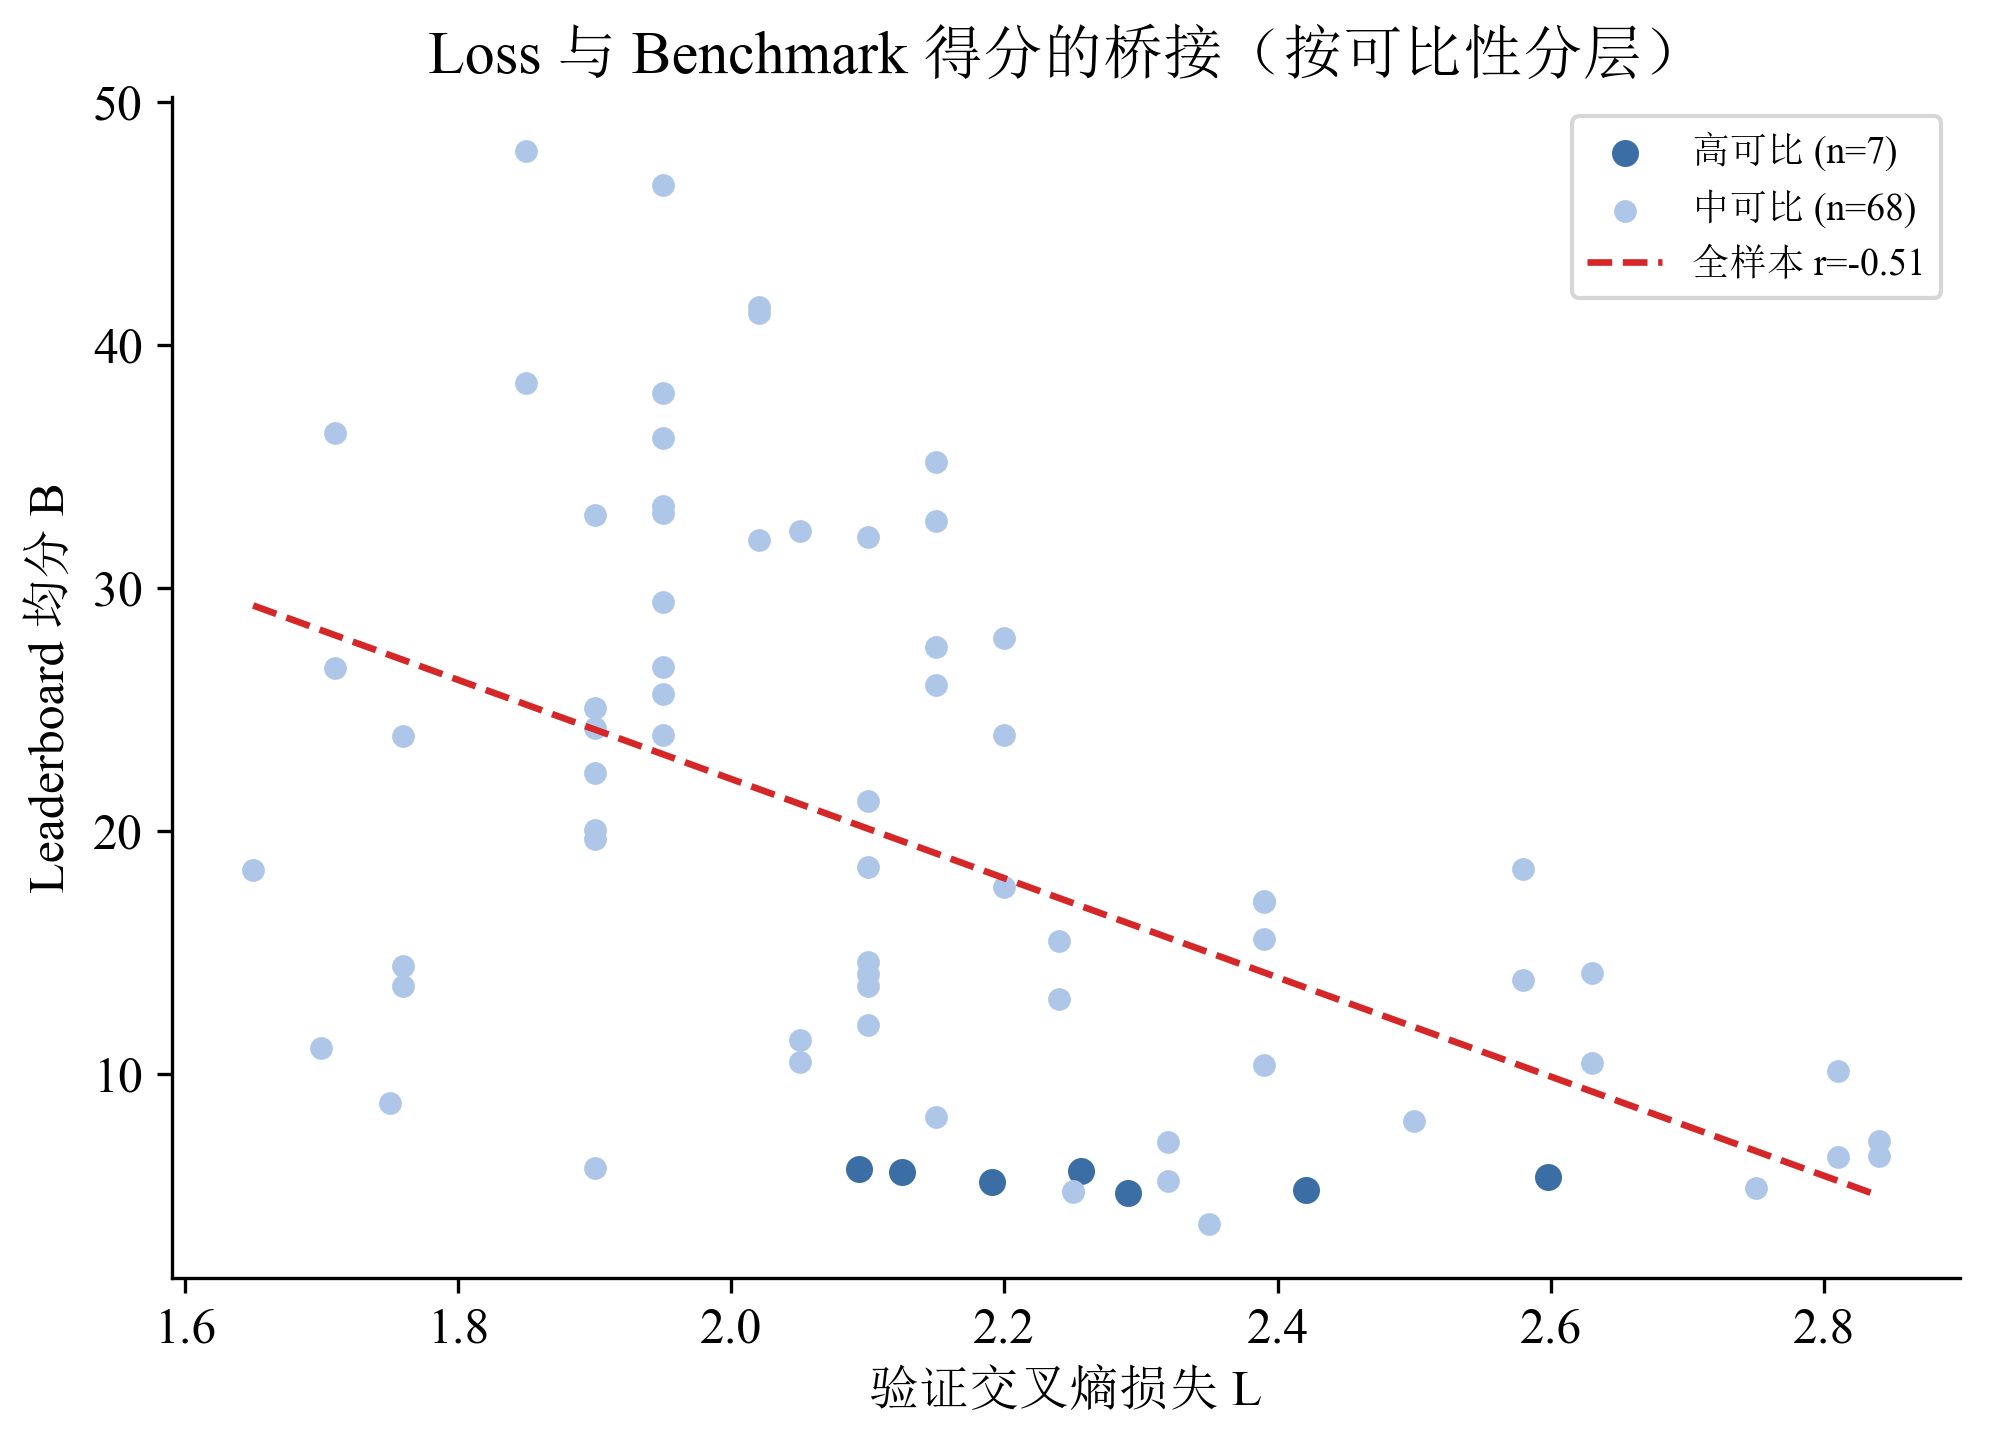

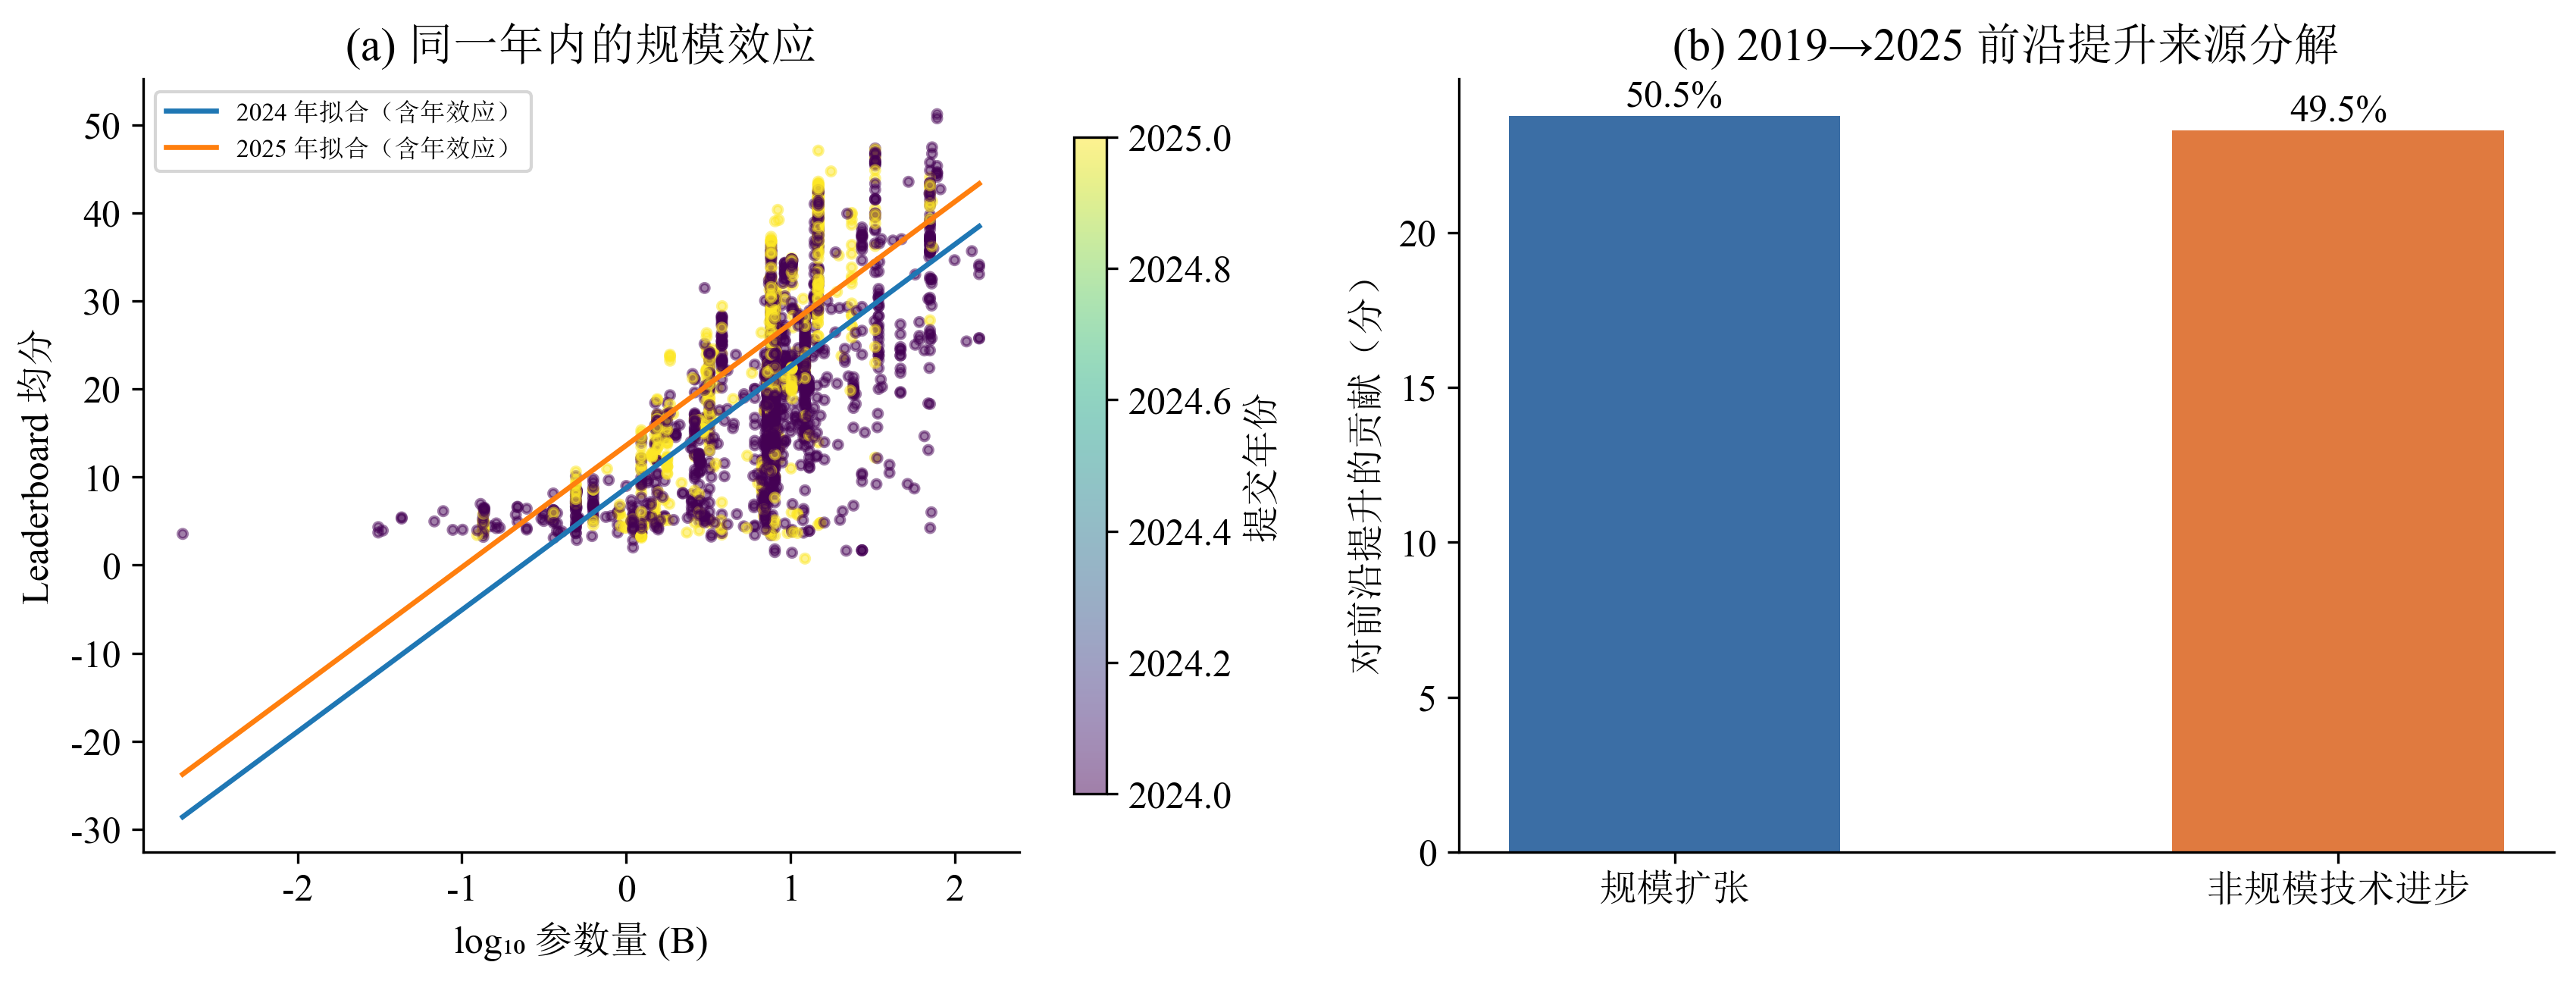

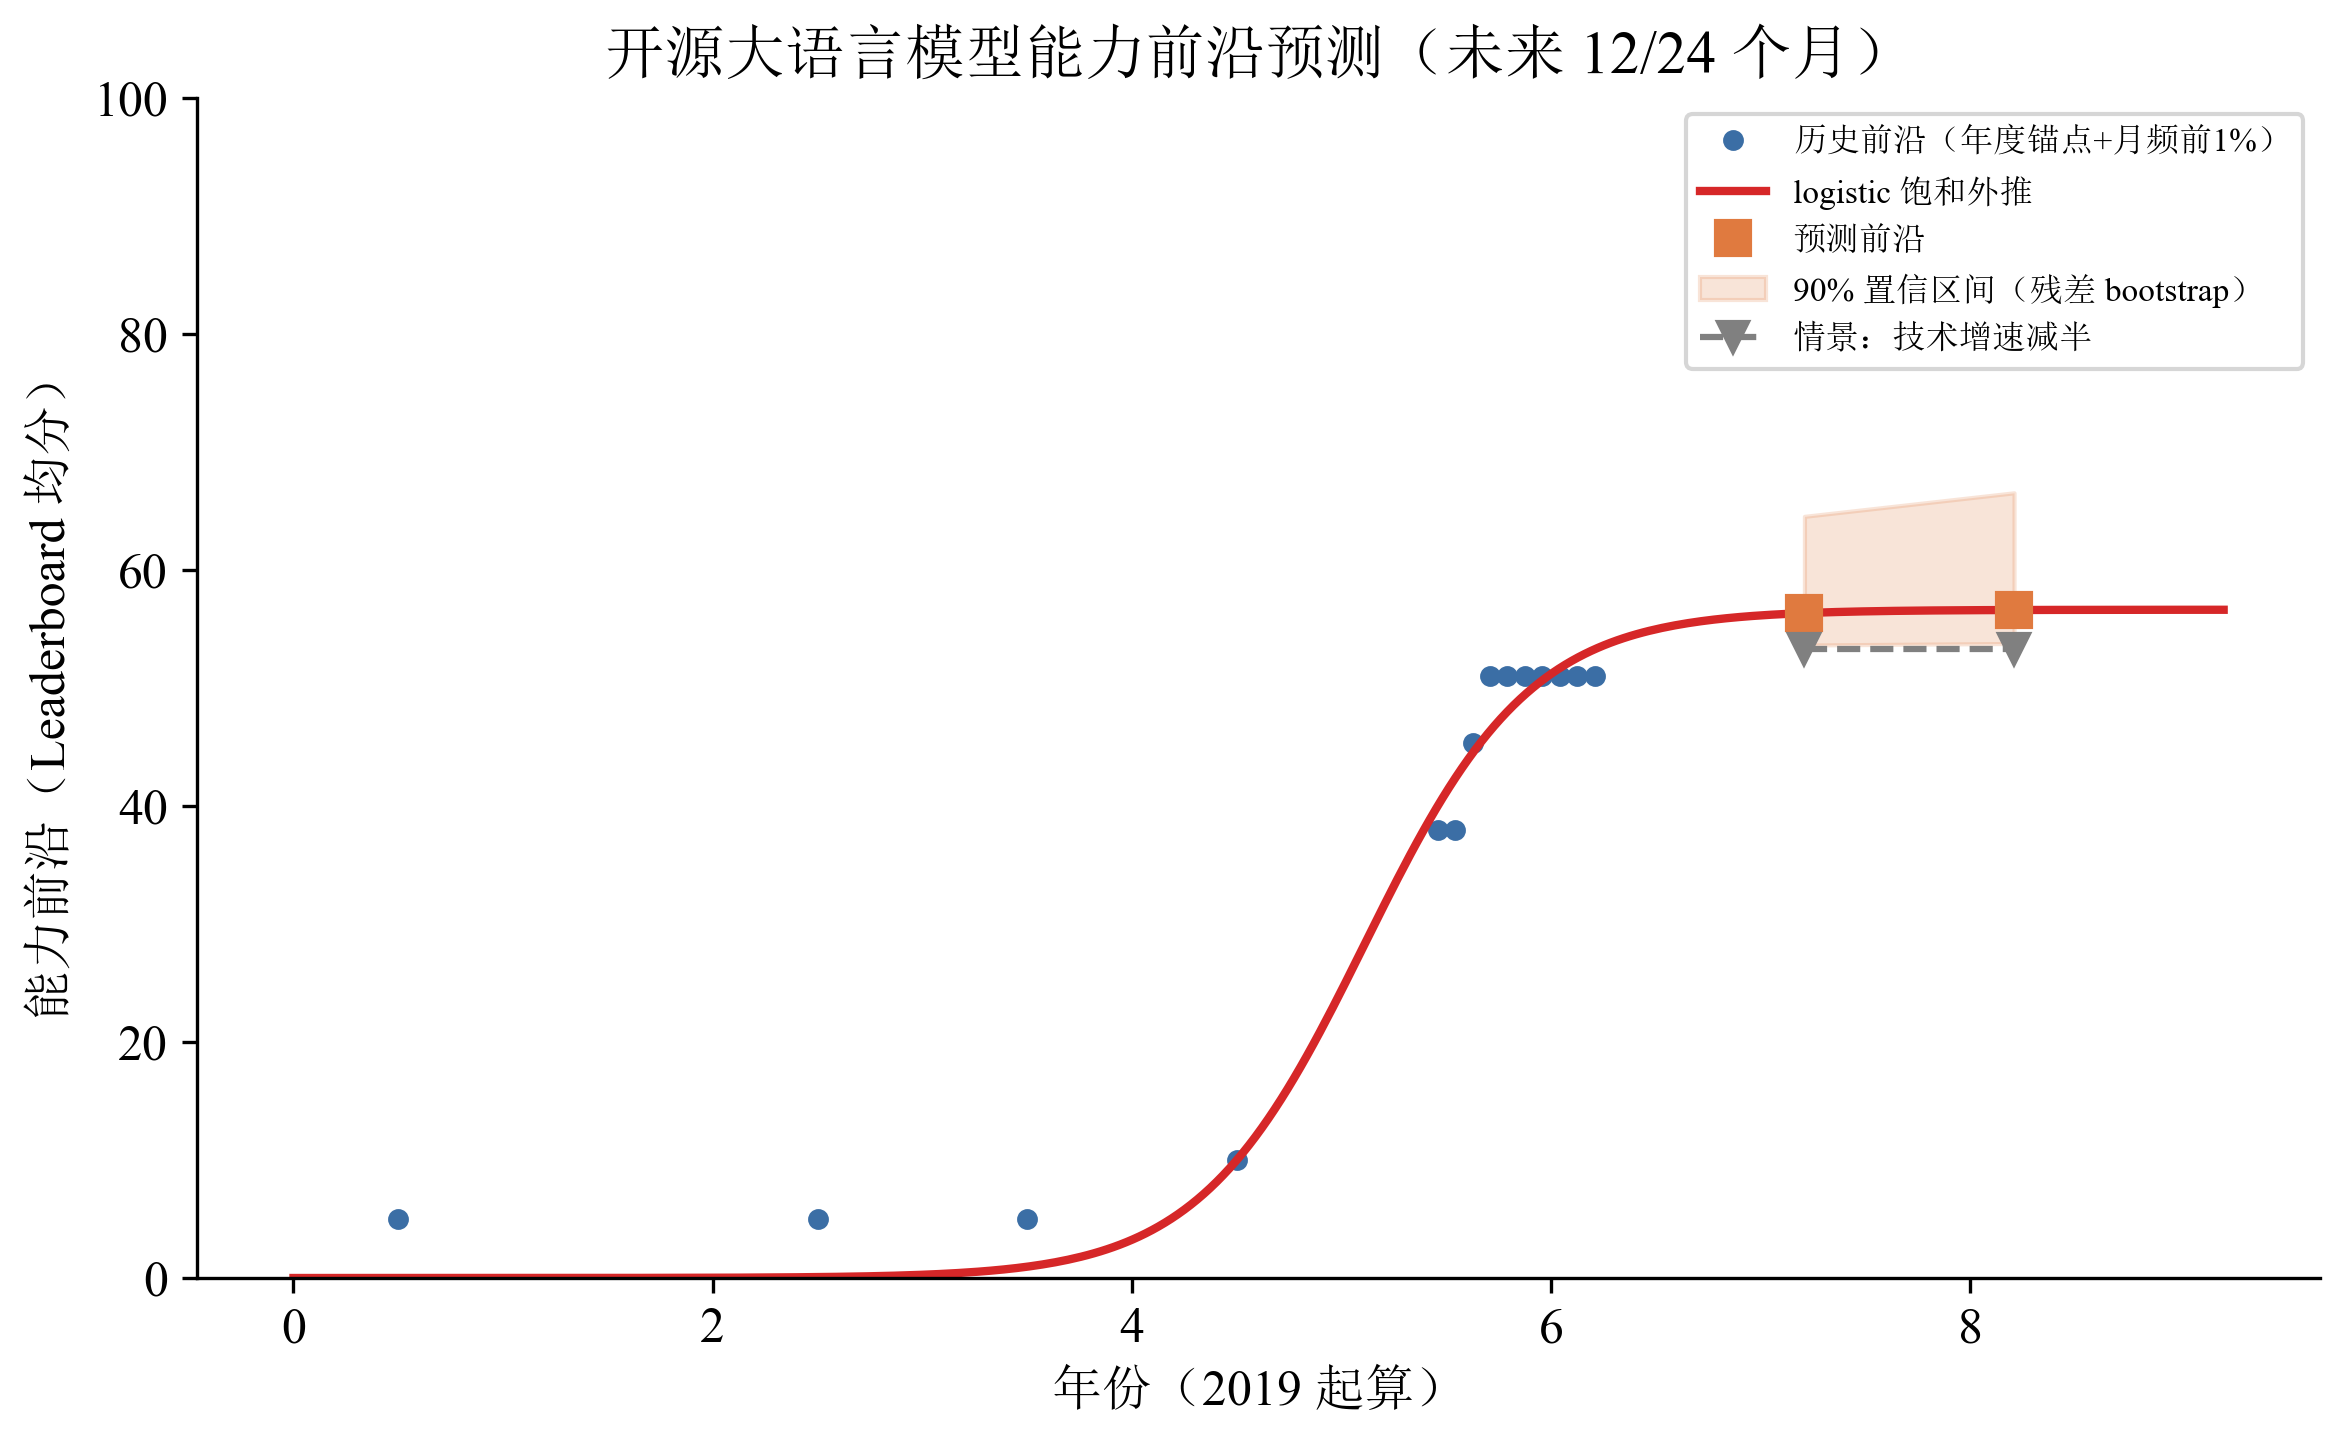

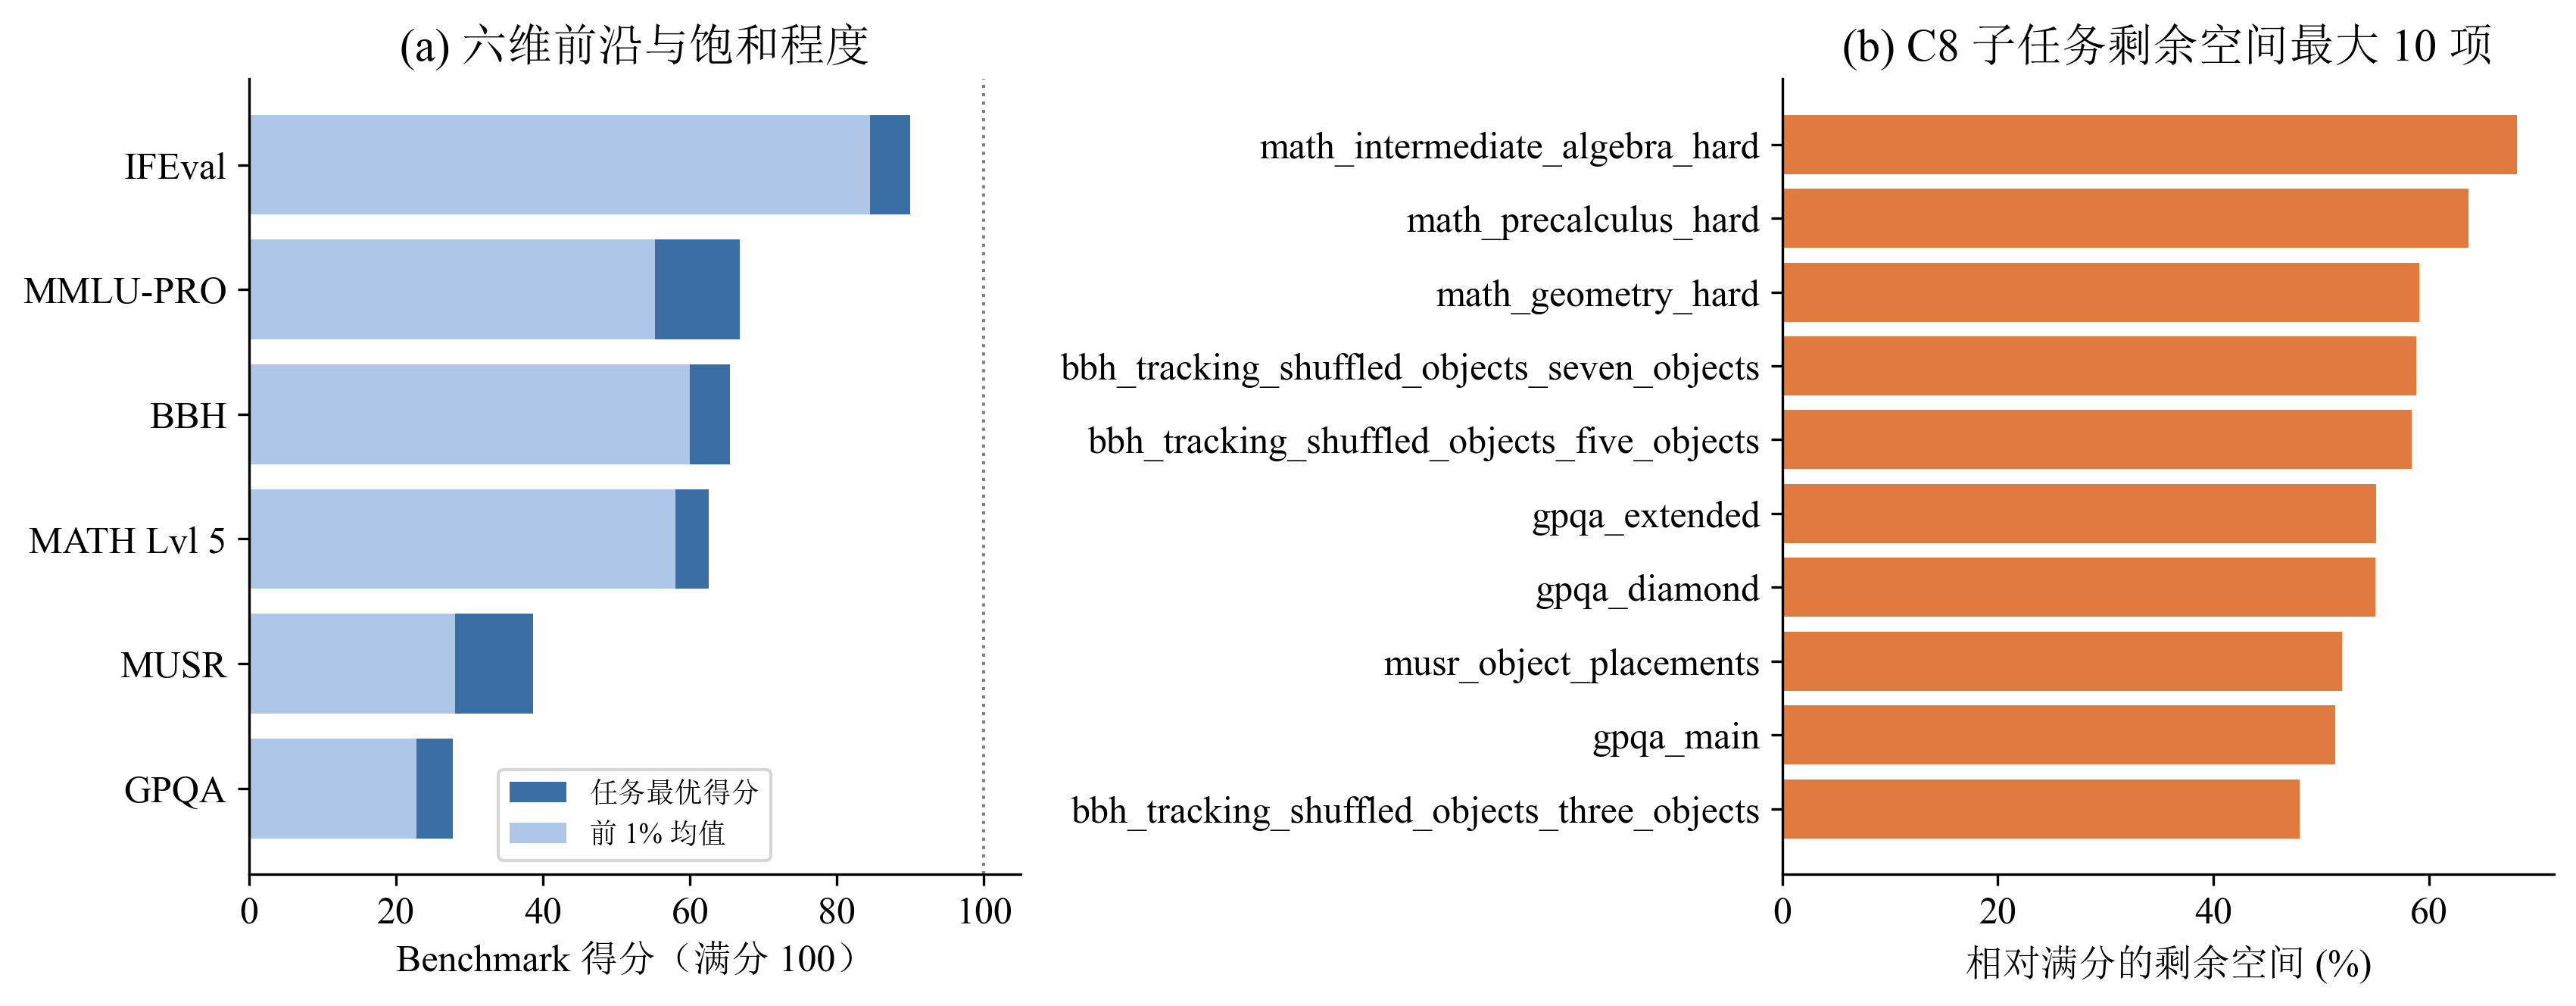

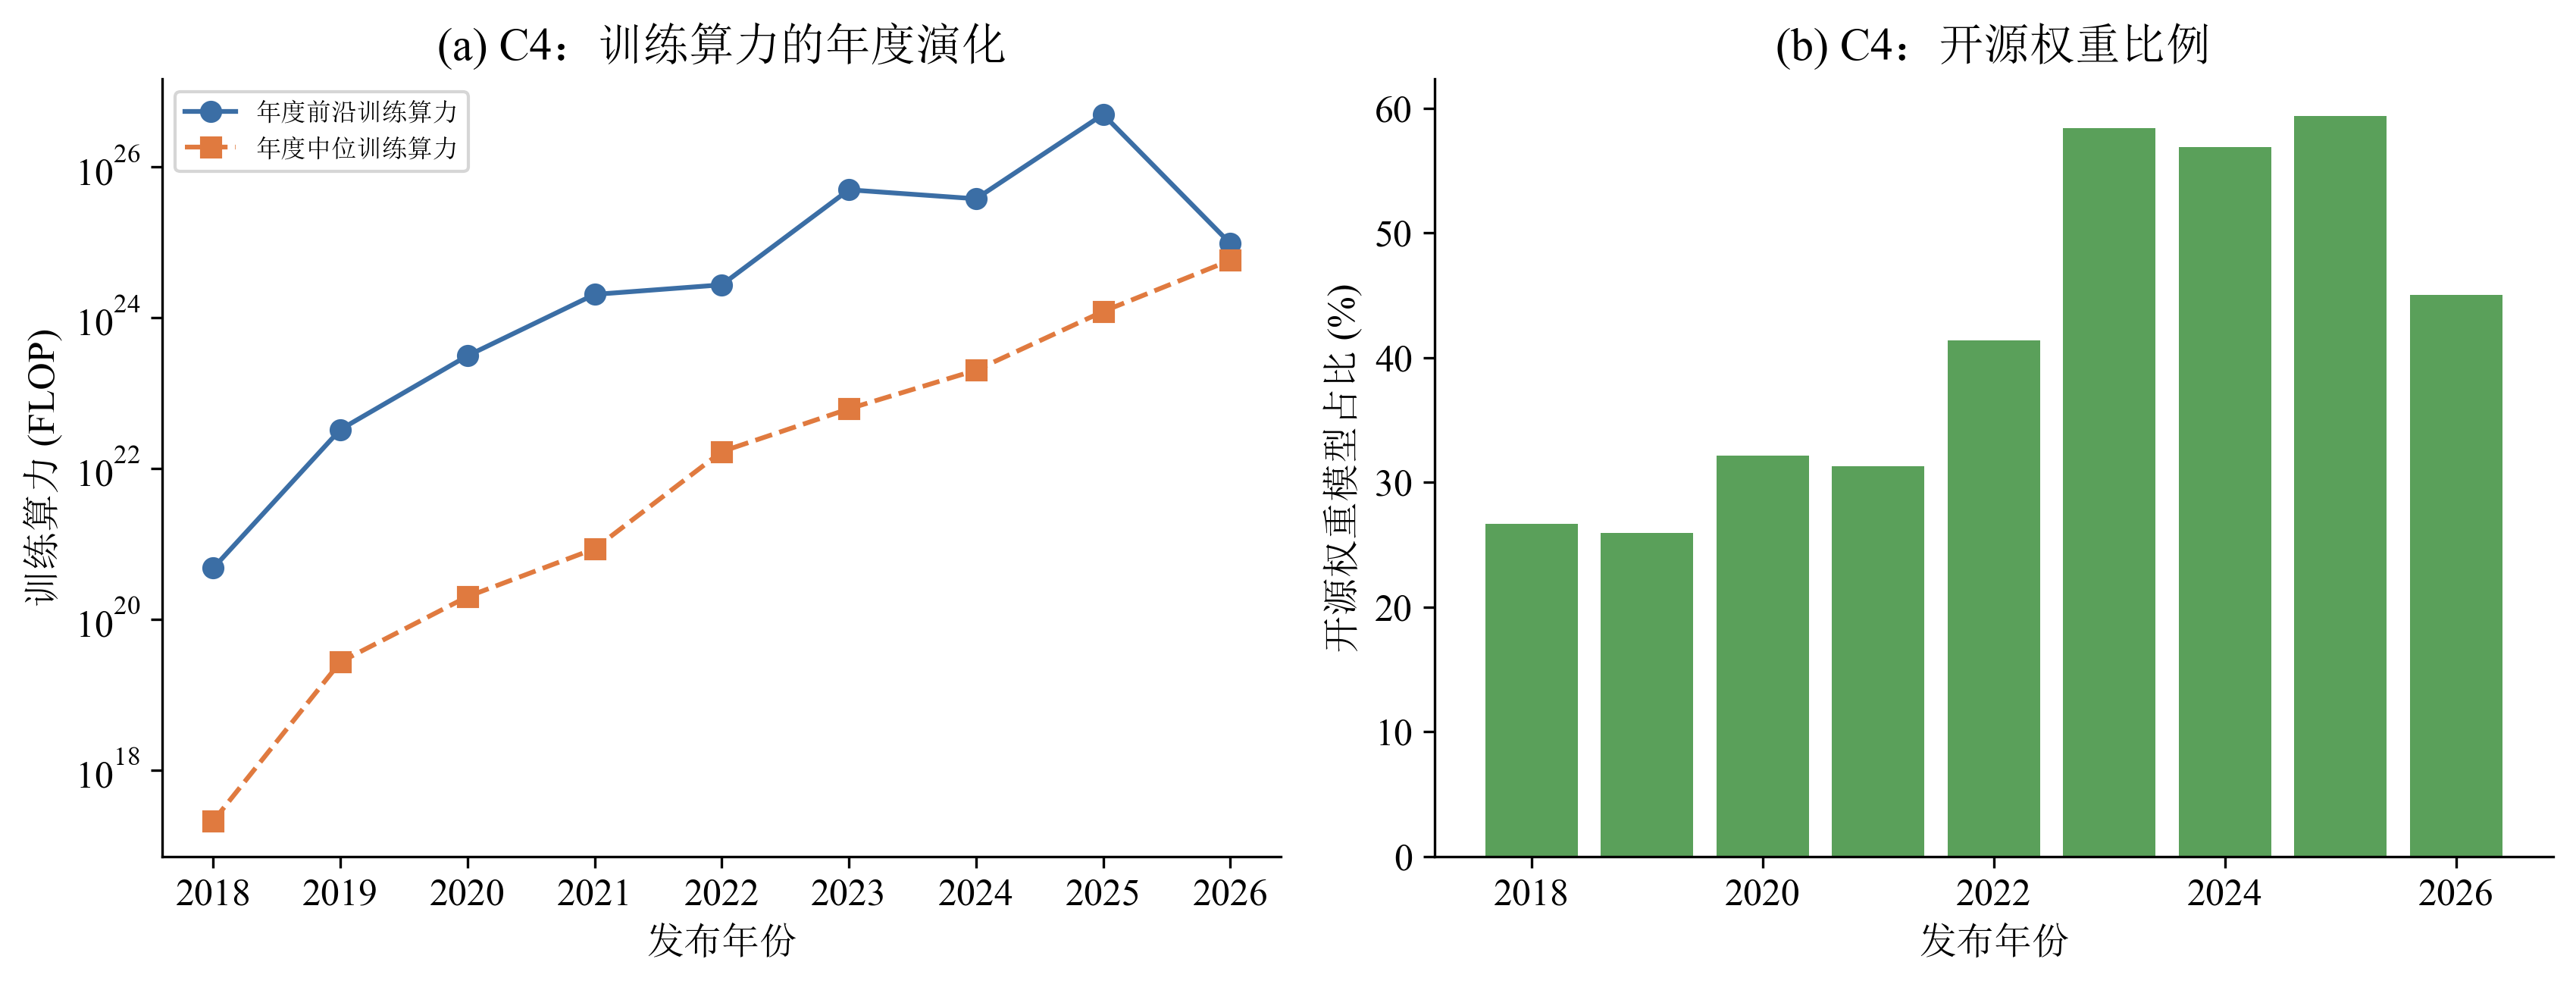

In [10]:
# ============ 8. 绘图 ============
plt.rcParams['font.size'] = 12
C1_, C2_, C3_ = '#3b6ea5', '#e07a3f', '#5aa05a'

fig, ax = plt.subplots(figsize=(6.8, 5))
hi_pt = br[br.cmp.eq('高可比')]; me_pt = br[br.cmp.eq('中可比')]
ax.scatter(hi_pt.Val_Loss, hi_pt.LB_Average, s=30, color=C1_,
           label='高可比 (n=%d)' % len(hi_pt))
ax.scatter(me_pt.Val_Loss, me_pt.LB_Average, s=20, color='#aec7e8',
           label='中可比 (n=%d)' % len(me_pt))
Ls = np.linspace(br.Val_Loss.min(), br.Val_Loss.max(), 50)
ax.plot(Ls, fits['全样本'][1] + fits['全样本'][0] * Ls, '--', color='#d62728', lw=1.6,
        label='全样本 r=%.2f' % bridge_df.iloc[2]['Pearson_r'])
ax.set_xlabel('验证交叉熵损失 L'); ax.set_ylabel('Leaderboard 均分 B')
ax.set_title('Loss 与 Benchmark 得分的桥接（按可比性分层）')
ax.legend(fontsize=9); despine(ax); fig.tight_layout(); save_fig(fig, '图1_Loss_Benchmark映射')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
ax = axes[0]
sc = ax.scatter(panel.logP, panel.avg, s=8, c=panel.Year, cmap='viridis', alpha=.5)
cb = fig.colorbar(sc, ax=ax, shrink=.85); cb.set_label('提交年份')
Pg = np.linspace(panel.logP.min(), panel.logP.max(), 50)
for yy in [2023, 2024, 2025]:
    k = yy - 2019
    if k in list(years):
        off = float(panel.loc[panel.t.eq(k), 'alpha_t'].iloc[0])
        ax.plot(Pg, off + bP_fe * Pg, lw=1.6, label='%d 年拟合（含年效应）' % yy)
ax.set_xlabel('log₁₀ 参数量 (B)'); ax.set_ylabel('Leaderboard 均分')
ax.set_title('(a) 同一年内的规模效应'); ax.legend(fontsize=8); despine(ax)
ax = axes[1]
d0 = dec.iloc[0]
ax.bar(['规模扩张', '非规模技术进步'], [d0['规模贡献分'], d0['非规模贡献分']],
       color=[C1_, C2_], width=.5)
for i, v in enumerate([d0['规模贡献分'], d0['非规模贡献分']]):
    ax.text(i, v + .3, '%.1f%%' % ([d0['规模占比%'], d0['非规模占比%']][i]), ha='center')
ax.set_ylabel('对前沿提升的贡献（分）')
ax.set_title('(b) %s 前沿提升来源分解' % d0['前沿区间']); despine(ax)
fig.tight_layout(); save_fig(fig, '图2_规模时间分解')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t_front, s_front, 'o', color=C1_, ms=4, label='历史前沿（年度锚点+月频前1%）')
tt = np.linspace(0, t_pred[-1] + 1, 300)
ax.plot(tt, logistic(tt, K_fit, r_fit, t0_fit), '-', color='#d62728', lw=2, label='logistic 饱和外推')
ax.plot(t_pred, s_pred, 's', color=C2_, ms=8, label='预测前沿')
ax.fill_between(t_pred, lo, hi, color=C2_, alpha=.2, label='90% 置信区间（残差 bootstrap）')
ax.plot(t_pred, s_slow, 'v--', color='gray', ms=7, label='情景：技术增速减半')
ax.set_xlabel('年份（2019 起算）'); ax.set_ylabel('能力前沿（Leaderboard 均分）')
ax.set_ylim(0, 100); ax.legend(fontsize=8); despine(ax)
ax.set_title('开源大语言模型能力前沿预测（未来 12/24 个月）')
fig.tight_layout(); save_fig(fig, '图3_能力前沿预测')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
ax = axes[0]
td = task_df.sort_values('max')
ax.barh(td['task'], td['max'], color=C1_, label='任务最优得分')
ax.barh(td['task'], td['top1_mean'], color='#aec7e8', label='前 1% 均值')
ax.axvline(100, color='gray', ls=':', lw=1)
ax.set_xlabel('Benchmark 得分（满分 100）'); ax.set_title('(a) 六维前沿与饱和程度')
ax.legend(fontsize=9); despine(ax)
ax = axes[1]
top = sub_df.nlargest(10, '剩余空间_%').sort_values('剩余空间_%')
ax.barh(top['子任务'], top['剩余空间_%'], color=C2_)
ax.set_xlabel('相对满分的剩余空间 (%)'); ax.set_title('(b) C8 子任务剩余空间最大 10 项')
despine(ax); fig.tight_layout(); save_fig(fig, '图4_逐任务聚合')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
ax = axes[0]
gg = g.dropna(subset=['前沿算力_max'])
ax.plot(gg.year, gg.前沿算力_max, 'o-', color=C1_, label='年度前沿训练算力')
ax.plot(gg.year, gg.前沿算力_中位, 's--', color=C2_, label='年度中位训练算力')
ax.set_yscale('log'); ax.set_xlabel('发布年份'); ax.set_ylabel('训练算力 (FLOP)')
ax.set_title('(a) C4：训练算力的年度演化'); ax.legend(fontsize=8); despine(ax)
ax = axes[1]
ax.bar(g.year, g.开源权重占比 * 100, color=C3_)
ax.set_xlabel('发布年份'); ax.set_ylabel('开源权重模型占比 (%)')
ax.set_title('(b) C4：开源权重比例'); despine(ax)
fig.tight_layout(); save_fig(fig, '图5_C4宏观趋势')


## 第 9 步：汇总

给出桥接精度、贡献分解（长周期与近端两个口径）、未来 12/24 个月前沿预测区间与逐任务瓶颈。

In [11]:
# ============ 9. 汇总 ============
print('\n===== 问题四求解完成 =====')
print('  桥接：全样本 r=%.3f；分解（%s）：规模 %.1f%% / 非规模 %.1f%%；'
      'OLS 版：规模 %.1f%% / 非规模 %.1f%%'
      % (bridge_df.iloc[2]['Pearson_r'], d0['前沿区间'], d0['规模占比%'], d0['非规模占比%'],
         dec_all.iloc[1]['规模占比%'], dec_all.iloc[1]['非规模占比%']))
print('  前沿预测（+12/+24 个月）：%s %.2f（90%%CI %.2f-%.2f）；%s %.2f（90%%CI %.2f-%.2f）；'
      '技术增速减半情景 %.2f / %.2f'
      % (fut['对应日历时点'].iloc[0], fut.frontier_pred.iloc[0], fut['CI_low_5%'].iloc[0],
         fut['CI_high_95%'].iloc[0], fut['对应日历时点'].iloc[1], fut.frontier_pred.iloc[1],
         fut['CI_low_5%'].iloc[1], fut['CI_high_95%'].iloc[1],
         fut['情景_技术增速减半'].iloc[0], fut['情景_技术增速减半'].iloc[1]))
print('\n  结构外推情景（基准前沿 F=%.2f）：' % F_last)
print(scen_df.round(2).to_string(index=False))
print('  两条路线互为校验：曲线外推（logistic）给出约 %.0f-%.0f，结构外推给出约 '
      '%.0f-%.0f；差异来自“前沿是否已饱和”的判断，故以区间而非点值作为结论。'
      % (min(fut.frontier_pred.min(), fut['CI_low_5%'].min()), fut['CI_high_95%'].max(),
         scen_df['结构外推前沿'].min(), scen_df['结构外推前沿'].max()))



===== 问题四求解完成 =====
  桥接：全样本 r=-0.510；分解（2019→2025）：规模 50.5% / 非规模 49.5%；OLS 版：规模 4.6% / 非规模 95.4%
  前沿预测（+12/+24 个月）：2026-03 56.33（90%CI 53.62-64.52）；2027-03 56.59（90%CI 53.75-66.52）；技术增速减半情景 53.27 / 53.27

  结构外推情景（基准前沿 F=51.00）：
                   情景  前瞻年数  Δlog10P假设  bt假设(分/年)  结构外推前沿
 基准（前沿模型规模持平，非规模增速不变）     1        0.0       4.84   55.84
      算力增长放缓（非规模增速减半）     1        0.0       2.42   53.42
规模继续扩张（前沿 +0.3 dex/年）     1        0.3       4.84   59.99
 基准（前沿模型规模持平，非规模增速不变）     2        0.0       4.84   60.69
      算力增长放缓（非规模增速减半）     2        0.0       2.42   55.84
规模继续扩张（前沿 +0.3 dex/年）     2        0.3       4.84   68.99
  两条路线互为校验：曲线外推（logistic）给出约 54-67，结构外推给出约 53-69；差异来自“前沿是否已饱和”的判断，故以区间而非点值作为结论。


## 结论解读与本问小结

1. **筛选口径**：C1 全量 4,576 条 → 六维与时间/参数齐备 4,561 条 → 许可允许研究复现 2,346 条（其中 pretrained 231、chat/finetuned 1,497）；base 合并模型 1,724 条与多模态 9 条不并入主分析。
2. **C8 逐任务聚合**：1,860 个模型成功解析、跳过 7 个损坏目录；解析出 BBH 24 + MATH 7 + GPQA 3 + MUSR 3 共 37 个子任务维度。与 C1 的秩相关为 0.81–0.998，说明两套数据反映同一批评测
   （水平差来自 C1 的随机基线归一化：GPQA $=(\text{raw}-0.25)/0.75$ 等）。
3. **桥接精度必须如实报告**：全样本 $r=-0.510$、$R^2=0.26$、MAPE 67.8% —— 只是弱关系；高可比子集（$n=7$）MAPE 最低（5.6%）但得分变化幅度极小（5.07–6.06），因为小基础模型在六维上都接近随机水平。因此桥接只用于**方向性判定**。
4. **贡献分解**：长周期（C3，2019→2025）规模扩张 50.5% / 非规模技术进步 49.5%；而在评测标准一致的近端窗口（2024-06→2024-09）内，前沿模型规模几乎没变，**非规模因素占 95.4%**。C3 的 13 条跨口径异常记录已剔除（最大差值 42.3）。
5. **能力前沿预测**（logistic $K=56.61$、$r=2.523$、$R^2=0.975$）：+12 个月约 56.3（90% CI 53.6–64.5），+24 个月约 56.6（90% CI 53.8–66.5）；非规模增速减半情景约 53.3–55.8；结构外推三情景给出 53.4–69.0 的区间。**结论以区间而非点值给出**，并明确说明一致窗口仅约 10 个月、外推期是其 1.2–2.4 倍。
6. **逐任务瓶颈**：IFEval 剩余空间仅 10.0%，而 GPQA 72.3%、MUSR 61.3%；子任务层面最弱的是 MATH 的中级代数（68.2%）、预备微积分（63.7%）、几何（59.1%）与 BBH 的"跟踪被洗牌对象"类多步状态推理（约 58%）。
7. **C4 宏观证据**：Language 域前沿训练算力年增速约 +0.589 个数量级（≈3.88 倍/年），但年际波动明显；开源权重模型占比由 2018 年 26.7% 升至 2025 年 59.4%。